DATASET INFORMATION
Shape : (21263, 82)

Top Correlated Features
                                                 Feature  Correlation  \
wtd_std_ThermalConductivity  wtd_std_ThermalConductivity     0.721271   
range_ThermalConductivity      range_ThermalConductivity     0.687654   
range_atomic_radius                  range_atomic_radius     0.653759   
std_ThermalConductivity          std_ThermalConductivity     0.653632   
wtd_mean_Valence                        wtd_mean_Valence    -0.632401   
wtd_entropy_atomic_mass          wtd_entropy_atomic_mass     0.626930   
wtd_gmean_Valence                      wtd_gmean_Valence    -0.615653   
wtd_entropy_atomic_radius      wtd_entropy_atomic_radius     0.603494   
number_of_elements                    number_of_elements     0.601069   
range_fie                                      range_fie     0.600790   
mean_Valence                                mean_Valence    -0.600085   
wtd_std_atomic_radius              wtd_std_atomic_radius   

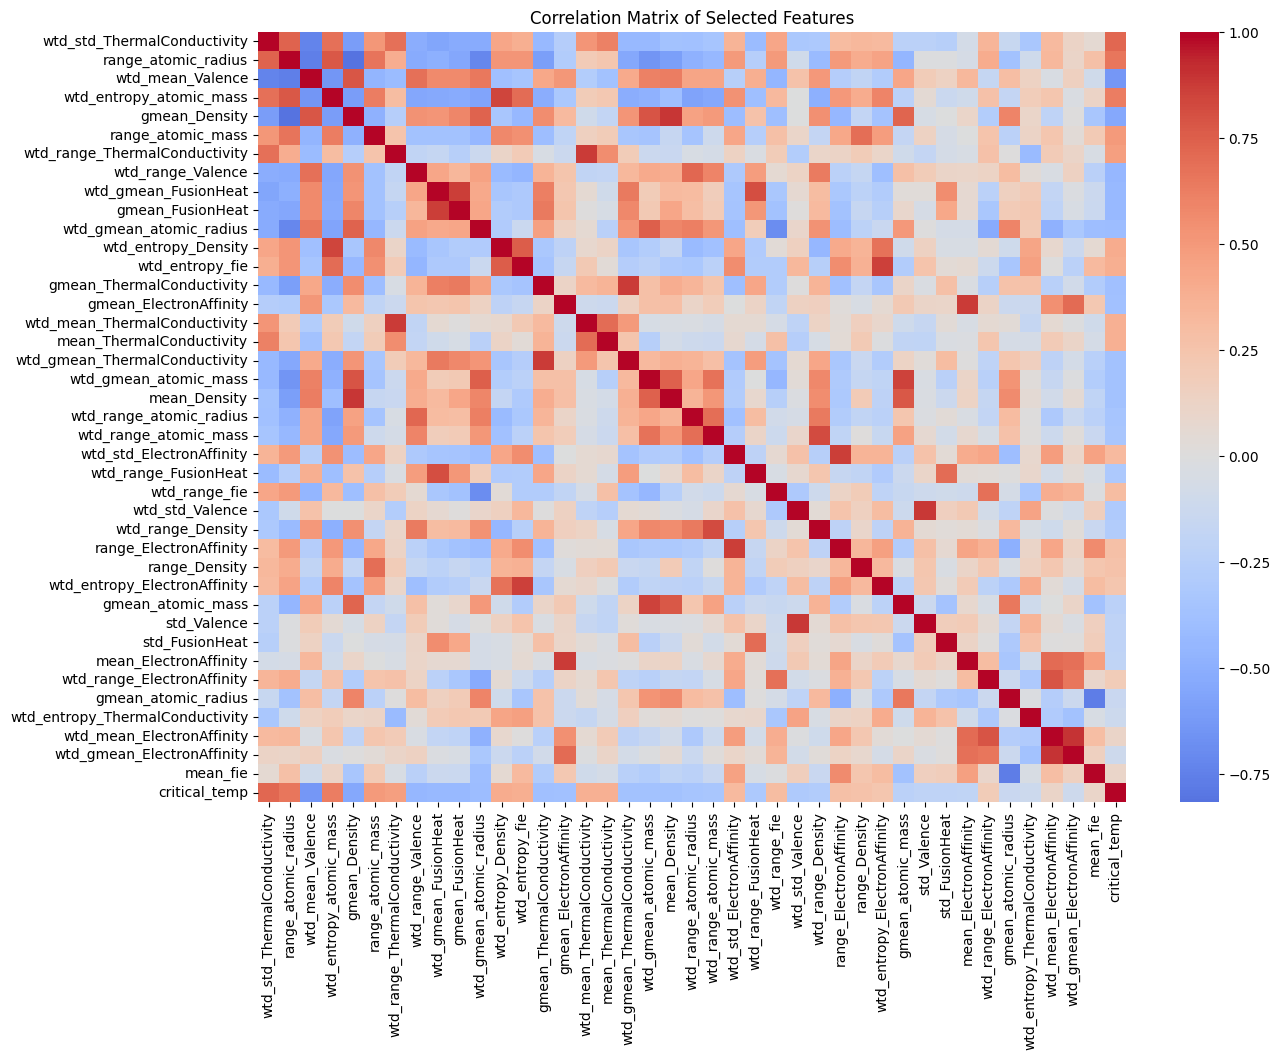



MODEL PERFORMANCE
MAE           : 14.2467
MSE           : 341.9412
RMSE          : 18.4917
R2 Score      : 0.7029
Adjusted R2   : 0.7001
MAPE          : 20.4846


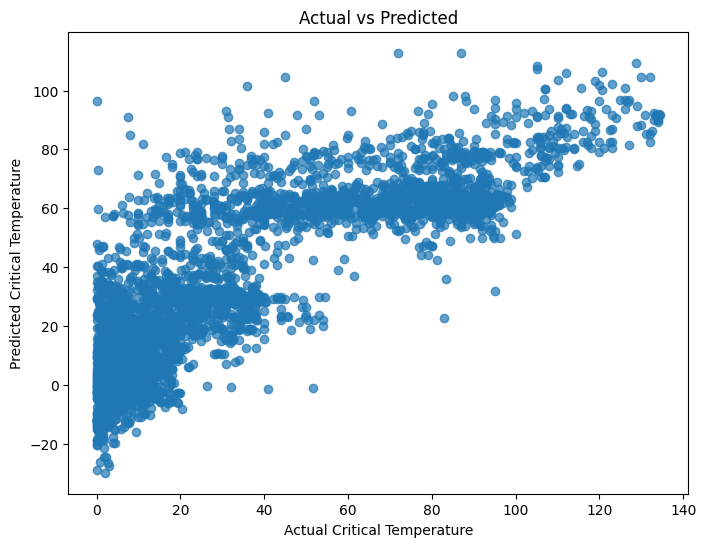

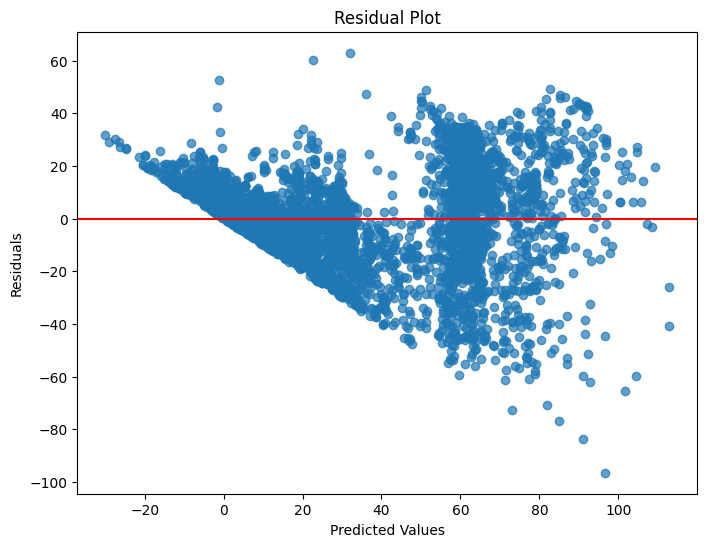



FEATURE IMPORTANCE
                            Feature  Coefficient  Absolute_Coefficient
15     wtd_mean_ThermalConductivity    19.087460             19.087460
38       wtd_gmean_ElectronAffinity   -14.121159             14.121159
17    wtd_gmean_ThermalConductivity   -12.625505             12.625505
37        wtd_mean_ElectronAffinity    12.458542             12.458542
25                  wtd_std_Valence    -8.777255              8.777255
1               range_atomic_radius     8.686818              8.686818
10          wtd_gmean_atomic_radius     8.169231              8.169231
5                 range_atomic_mass     7.765645              7.765645
3           wtd_entropy_atomic_mass     7.039000              7.039000
29     wtd_entropy_ElectronAffinity    -6.194415              6.194415
33            mean_ElectronAffinity     5.863121              5.863121
34       wtd_range_ElectronAffinity    -5.385690              5.385690
7                 wtd_range_Valence     5.158335        

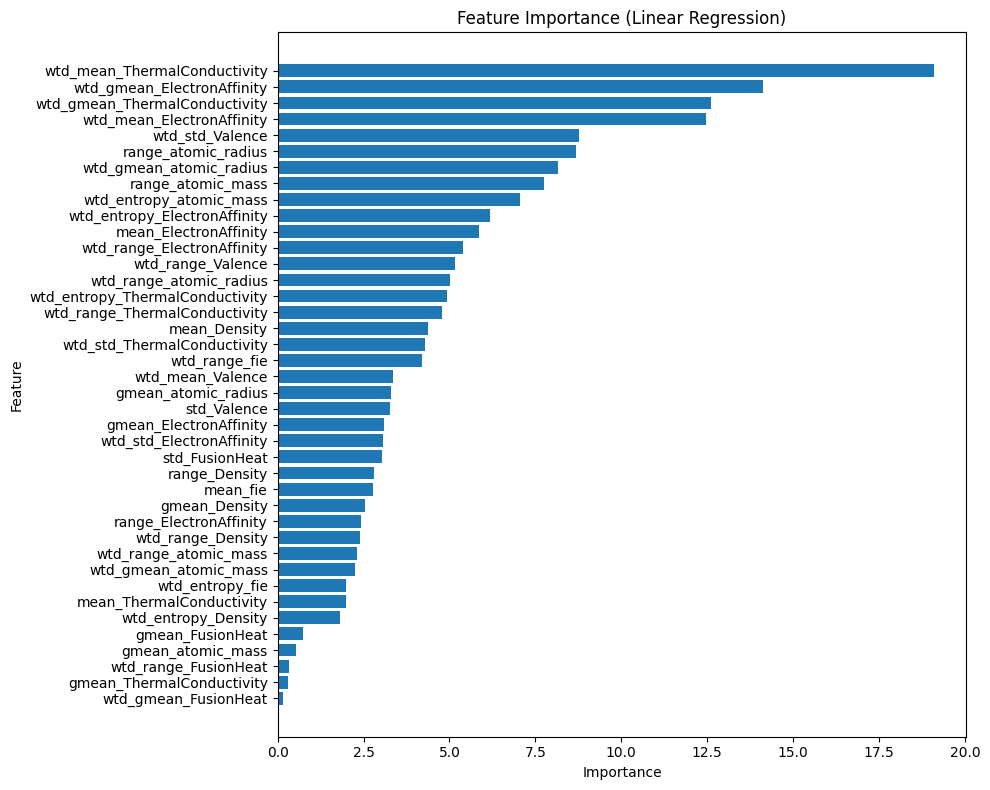

In [2]:
# ============================================================
# SUPERCONDUCTOR CRITICAL TEMPERATURE PREDICTION
# LINEAR REGRESSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("train.csv")

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Shape :", df.shape)

# ============================================================
# TARGET VARIABLE
# ============================================================

target = "critical_temp"

# ============================================================
# INPUT AND OUTPUT
# ============================================================

X = df.drop(columns=[target])
y = df[target]

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())
y = y.fillna(y.median())

# ============================================================
# FEATURE SELECTION USING CORRELATION
# ============================================================

correlation = X.corrwith(y)

correlation_table = pd.DataFrame({
    "Feature": X.columns,
    "Correlation": correlation,
    "Absolute_Correlation": abs(correlation)
})

correlation_table = correlation_table.sort_values(
    by="Absolute_Correlation",
    ascending=False
)

print("\nTop Correlated Features")
print(correlation_table.head(20))

# ============================================================
# SELECT IMPORTANT FEATURES
# ============================================================

threshold = 0.10

important_features = correlation_table[
    correlation_table["Absolute_Correlation"] >= threshold
]["Feature"].tolist()

print("\nNumber of Important Features:",
      len(important_features))

X = X[important_features]

# ============================================================
# REMOVE MULTICOLLINEAR FEATURES
# ============================================================

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

drop_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

print("\nFeatures Removed due to Multicollinearity:")
print(drop_features)

X = X.drop(columns=drop_features)

print("\nFinal Feature Count:", X.shape[1])

# ============================================================
# FINAL CORRELATION MATRIX
# ============================================================

final_df = pd.concat([X, y], axis=1)

plt.figure(figsize=(14,10))

sns.heatmap(
    final_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Selected Features"
)

plt.show()

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_scaled)

# ============================================================
# EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    ((1-r2)*(n-1))
    /
    (n-p-1)
)

print("\n")
print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"MAE           : {mae:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"R2 Score      : {r2:.4f}")
print(f"Adjusted R2   : {adj_r2:.4f}")
print(f"MAPE          : {mape:.4f}")

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")

plt.title(
    "Actual vs Predicted"
)

plt.show()

# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    "Residual Plot"
)

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["Absolute_Coefficient"] = (
    importance["Coefficient"].abs()
)

importance = importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n")
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance)

# ============================================================
# FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Absolute_Coefficient"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance (Linear Regression)"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()